# Building an AI-powered multimodal RAG system with Docling and Granite

*Using IBM Granite vision, text-based embeddings and generative AI models*

## Multimodal retrieval-augmented generation

[Retrieval-augmented generation (RAG)](https://www.ibm.com/think/topics/retrieval-augmented-generation) is a technique used with large language models (LLMs) to connect the model with a knowledge base of information outside the data the LLM has been trained on without having to perform [fine-tuning](https://www.ibm.com/think/topics/rag-vs-fine-tuning). Traditional RAG is limited to text-based use cases such as text summarization and chatbots.

Multimodal RAG can use [multimodal](https://www.ibm.com/think/topics/multimodal-ai) LLMs (MLLM) to process information from multiple types of data to be included as part of the external knowledge base used in RAG. Multimodal data can include text, images, audio, video or other forms. Popular multimodal LLMs include Google’s Gemini, Meta’s Llama 3.2 and OpenAI’s GPT-4 and GPT-4o.

For this recipe, you will use an IBM Granite model capable of processing different modalities. You will create an AI system to answer real-time user queries from unstructured data in a PDF.

## Recipe overview

Welcome to this Granite recipe. In this recipe, you'll learn how to harness the power of advanced tools to build an AI-powered multimodal RAG pipeline. This tutorial will guide you through the following processes:

- **Document preprocessing:** Learn how to handle documents from various sources, parse and transform them into usable formats and store them in vector databases by using Docling. You will use a Granite MLLM to generate image descriptions of images in the documents.
- **RAG:** Understand how to connect LLMs such as Granite with external knowledge bases to enhance query responses and generate valuable insights.
- **LangChain for workflow integration:** Discover how to use LangChain to streamline and orchestrate document processing and retrieval workflows, enabling seamless interaction between different components of the system.

This recipe uses three cutting-edge technologies:

1. **[Docling](https://docling-project.github.io/docling/):** An open-source toolkit used to parse and convert documents.
2. **[Granite](https://www.ibm.com/granite/docs/models/granite/):** A state-of-the-art LLM that provides robust natural language capabilities and a vision language model that provides image to text generation.
3. **[LangChain](https://github.com/langchain-ai/langchain):** A powerful framework used to build applications powered by language models, designed to simplify complex workflows and integrate external tools seamlessly.

By the end of this recipe, you will accomplish the following:
- Gain proficiency in document preprocessing, chunking and image understanding.
- Integrate vector databases to enhance retrieval capabilities.
- Use RAG to perform efficient and accurate data retrieval for real-world applications.

This recipe is designed for AI developers, researchers and enthusiasts looking to enhance their knowledge of document management and advanced natural language processing (NLP) techniques.


## Prerequisites

- Familiarity with Python programming.
- Basic understanding of LLMs, NLP concepts and computer vision.

## Step 1: Setting up the environment

Install dependencies.

In [1]:
! echo "::group::Install Dependencies"
%pip install uv
! uv pip install "git+https://github.com/ibm-granite-community/utils.git" \
    transformers \
    pillow \
    langchain_classic \
    langchain_core \
    langchain_huggingface sentence_transformers \
    langchain_chroma chromadb \
    docling \
    "langchain_replicate @ git+https://github.com/ibm-granite-community/langchain-replicate.git"
! echo "::endgroup::"

::group::Install Dependencies
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 18.9 MB/s eta 0:00:00
Using Python 3.12.13 environment at: /usr
Resolved 156 packages in 13.94s
Prepared 48 packages in 5.24s
Uninstalled 3 packages in 665ms
Installed 48 packages in 463ms
 + bcrypt==5.0.0
 + build==1.5.0
 + chromadb==1.5.9
 + colorlog==6.10.1
 + docling==2.93.0
 + docling-core==2.75.0
 + docling-ibm-models==3.13.2
 + docling-parse==5.11.0
 + docling-slim==2.93.0
 + durationpy==0.10
 + faker==40.15.0
 + filetype==1.2.0
 + ibm-granite-community-utils==0.1.dev160 (from git+https://github.com/ibm-granite-community/utils.git@f94b8d70a9189364083538877ae35b597e43d3d1)
 + jsonlines==4.0.0
 + jsonref==1.1.0
 + kubernetes==35.0.0
 + langchain-chroma==1.1.0
 + langchain-classic==1.0.7
 - langchain-core==1.3.1
 + langchain-core==1.4.0
 + langchain-huggingface==1.2.2
 + langchain-protocol==0.0.15
 + langchain-replicate==0.1.dev26 (from git+https://github.com/ibm-granite-community/langchain-repli

## Step 2: Selecting the AI models

### Logging

To see some logging information, we can configure INFO log level.

NOTE: It is okay to skip running this cell.

In [2]:
import logging

logging.basicConfig(level=logging.INFO)

### Load the Granite models

Specify the embeddings model to use for generating text embedding vectors. Here we will use one of the [Granite Embeddings models](https://huggingface.co/collections/ibm-granite/granite-embedding-models-6750b30c802c1926a35550bb)

To use a different embeddings model, replace this code cell with one from [this Embeddings Model recipe](https://github.com/ibm-granite-community/granite-kitchen/blob/main/recipes/Components/Langchain_Embeddings_Models.ipynb).

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
from transformers import AutoTokenizer

embeddings_model_path = "ibm-granite/granite-embedding-small-english-r2"
embeddings_model = HuggingFaceEmbeddings(
    model_name=embeddings_model_path,
)
embeddings_tokenizer = AutoTokenizer.from_pretrained(embeddings_model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/55.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/95.3M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Specify the MLLM to use for image understanding. We will use the Granite vision model.

In [4]:
from ibm_granite_community.notebook_utils import get_env_var
from langchain_replicate import Replicate
from transformers import AutoProcessor

vision_model_path = "ibm-granite/granite-vision-3.3-2b"

# IMPORTANT: The 'REPLICATE_API_TOKEN' was not found during the last execution.
# To fix this, please add your Replicate API token to Google Colab secrets:
# 1. Click on the '🔑' icon (Secrets) in the left sidebar.
# 2. Add a new secret with the name 'REPLICATE_API_TOKEN' and its value.
# 3. Ensure 'Notebook access' is enabled for this notebook.
vision_model = Replicate(
    model=vision_model_path,
    replicate_api_token=get_env_var("REPLICATE_API_TOKEN"),
    model_kwargs={
        "max_tokens": embeddings_tokenizer.max_len_single_sentence, # Set the maximum number of tokens to generate as output.
        "min_tokens": 100, # Set the minimum number of tokens to generate as output.
    },
)
vision_processor = AutoProcessor.from_pretrained(vision_model_path)

REPLICATE_API_TOKEN not found in Google Colab secrets.
Please enter your REPLICATE_API_TOKEN: ··········


processor_config.json:   0%|          | 0.00/174 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/107 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

Specify the language model to use for the RAG generation operation. Here we use the Replicate LangChain client to connect to a Granite model from the [`ibm-granite`](https://replicate.com/ibm-granite) org on Replicate.

To get set up with Replicate, see [Getting Started with Replicate](https://github.com/ibm-granite-community/granite-kitchen/blob/main/recipes/Getting_Started/Getting_Started_with_Replicate.ipynb).

To connect to a model on a provider other than Replicate, substitute this code cell with one from the [LLM component recipe](https://github.com/ibm-granite-community/granite-kitchen/blob/main/recipes/Components/Langchain_LLMs.ipynb).

In [5]:
from langchain_replicate import ChatReplicate

model_path = "ibm-granite/granite-4.1-8b"
model = ChatReplicate(
    model=model_path,
    replicate_api_token=get_env_var("REPLICATE_API_TOKEN"),
    model_kwargs={
        "max_tokens": 1000, # Set the maximum number of tokens to generate as output.
        "min_tokens": 100, # Set the minimum number of tokens to generate as output.
    },
)

## Step 3: Preparing the documents for the vector database

In this example, from a set of source documents, we use [Docling](https://docling-project.github.io/docling/) to convert the documents into text and images. The text is then split into chunks. The images are processed by the MLLM to generate image summaries.

### Use Docling to download the documents and convert to text and images

Docling will download the PDF documents and process them so we can obtain the text and images the documents contain. In the PDF, there are various data types, including text, tables, graphs and images.

In [6]:
from docling.document_converter import DocumentConverter, PdfFormatOption
from docling.datamodel.base_models import InputFormat
from docling.datamodel.pipeline_options import PdfPipelineOptions
from urllib.parse import urlparse

pdf_pipeline_options = PdfPipelineOptions(
    do_ocr=False,
    generate_picture_images=True,
)
format_options = {
    InputFormat.PDF: PdfFormatOption(pipeline_options=pdf_pipeline_options),
}
converter = DocumentConverter(format_options=format_options)

sources = [
    "https://web.archive.org/web/20230523232035if_/https://www.midwestfoodbank.org/images/AR_2020_WEB2.pdf",
]
conversions = { urlparse(source).path.rstrip("/").split("/")[-1]: converter.convert(source=source).document for source in sources }

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

With the documents processed, we then further process the text elements in the documents. We chunk them into appropriate sizes for the embeddings model we are using. A list of LangChain documents are created from the text chunks.

In [7]:
from docling_core.transforms.chunker.hybrid_chunker import HybridChunker
from docling_core.types.doc.document import TableItem
from langchain_core.documents import Document

doc_id = 0
texts: list[Document] = []
for source, docling_document in conversions.items():
    for chunk in HybridChunker(tokenizer=embeddings_tokenizer).chunk(docling_document):
        items = chunk.meta.doc_items
        if len(items) == 1 and isinstance(items[0], TableItem):
            continue # we will process tables later
        refs = " ".join(map(lambda item: item.get_ref().cref, items))
        print(refs)
        text = chunk.text
        document = Document(
            page_content=text,
            metadata={
                "doc_id": (doc_id:=doc_id+1),
                "source": source,
                "ref": refs,
            },
        )
        texts.append(document)

print(f"{len(texts)} text document chunks created")

#/texts/1
#/texts/4 #/texts/5 #/texts/6 #/texts/7 #/texts/8 #/texts/9 #/texts/10 #/texts/11 #/texts/12 #/texts/13
#/tables/0 #/texts/16 #/texts/17 #/texts/18
#/texts/21
#/texts/23
#/texts/25
#/texts/27
#/texts/29
#/texts/31
#/texts/33
#/texts/35 #/texts/38 #/texts/39 #/texts/40 #/texts/41
#/texts/45 #/texts/46
#/texts/48 #/texts/49 #/texts/50 #/texts/51 #/texts/52 #/texts/53 #/texts/54 #/texts/55 #/texts/56 #/texts/57
#/texts/59 #/texts/60 #/texts/61 #/texts/62 #/texts/63 #/texts/64 #/texts/65
#/texts/141
#/tables/1 #/texts/145 #/texts/153
#/texts/157 #/texts/158
#/texts/160 #/texts/161 #/texts/162
#/texts/166 #/texts/167 #/texts/168 #/texts/169
#/texts/182
#/texts/184 #/texts/185 #/texts/186 #/texts/187 #/texts/188 #/texts/189 #/texts/190
#/texts/193
#/texts/195
#/texts/197
#/texts/199
#/texts/201
#/texts/203
#/texts/205
#/texts/207
#/texts/209
#/texts/211
#/texts/213
#/texts/215
#/texts/217
#/texts/225 #/texts/226 #/texts/227
#/texts/229 #/texts/230
#/texts/232
#/texts/235 #/texts/23

Next we process any tables in the documents. We convert the table data to markdown format for passing into the language model. A list of LangChain documents are created from the table's markdown renderings.

In [8]:
from docling_core.types.doc.labels import DocItemLabel

doc_id = len(texts)
tables: list[Document] = []
for source, docling_document in conversions.items():
    for table in docling_document.tables:
        if table.label in [DocItemLabel.TABLE]:
            ref = table.get_ref().cref
            print(ref)
            text = table.export_to_markdown(docling_document)
            document = Document(
                page_content=text,
                metadata={
                    "doc_id": (doc_id:=doc_id+1),
                    "source": source,
                    "ref": ref
                },
            )
            tables.append(document)


print(f"{len(tables)} table documents created")

#/tables/1
1 table documents created


Finally we process any images in the documents. Here we use the vision language model to understand the content of an image. In this example, we are interested in any textual information in the image. You might want to experiment with different prompt text to see how it might improve the results.

NOTE: Processing the images can take a very long time depending upon the number of images and the service running the vision language model.

In [21]:
import base64
import io
import PIL.Image
import PIL.ImageOps
from ibm_granite_community.langchain.prompts import TokenizerChatPromptTemplate
from langchain_core.messages import HumanMessage
import time # Import the time module for delays

def encode_image(image: PIL.Image.Image, format: str = "png") -> str:
    image = PIL.ImageOps.exif_transpose(image) or image
    image = image.convert("RGB")

    buffer = io.BytesIO()
    image.save(buffer, format)
    encoding = base64.b64encode(buffer.getvalue()).decode("utf-8")
    uri = f"data:image/{format};base64,{encoding}"
    return uri

# Feel free to experiment with this prompt
image_prompt = "If the image contains text, explain the text in the image."
vision_prompt_template = TokenizerChatPromptTemplate.from_messages(
    messages=[
        HumanMessage(content=[
            {"type": "image"},
            {"type": "text", "text": image_prompt},
        ]),
    ],
    tokenizer=vision_processor)
vision_prompt = vision_prompt_template.format_prompt()

pictures: list[Document] = []
doc_id = len(texts) + len(tables)
processed_count = 0
total_pictures_to_process = sum(len(docling_document.pictures) for docling_document in conversions.values())
print(f"Starting image processing. Total pictures to process: {total_pictures_to_process}")

try:
    for source, docling_document in conversions.items():
        for picture in docling_document.pictures:
            ref = picture.get_ref().cref
            image = picture.get_image(docling_document)
            if image:
                text = vision_model.invoke(vision_prompt, images=[encode_image(image)])
                document = Document(
                    page_content=text,
                    metadata={
                        "doc_id": (doc_id:=doc_id+1),
                        "source": source,
                        "ref": ref,
                    },
                )
                pictures.append(document)
                processed_count += 1
                print(f"Processed {processed_count}/{total_pictures_to_process} images. Last processed: {ref}") # Print progress
                time.sleep(10) # Add a delay to avoid Replicate API rate limits
except KeyboardInterrupt:
    print(f"\nImage processing interrupted by user. {processed_count} images processed so far.")
    print("The 'pictures' list contains descriptions for processed images only.")
    print("Please re-run this cell to continue processing or ensure it runs to completion.")

print(f"{len(pictures)} image descriptions created")

Starting image processing. Total pictures to process: 54
Processed 1/54 images. Last processed: #/pictures/0
Processed 2/54 images. Last processed: #/pictures/1
Processed 3/54 images. Last processed: #/pictures/2
Processed 4/54 images. Last processed: #/pictures/3
Processed 5/54 images. Last processed: #/pictures/4
Processed 6/54 images. Last processed: #/pictures/5
Processed 7/54 images. Last processed: #/pictures/6
Processed 8/54 images. Last processed: #/pictures/7
Processed 9/54 images. Last processed: #/pictures/8
Processed 10/54 images. Last processed: #/pictures/9
Processed 11/54 images. Last processed: #/pictures/10
Processed 12/54 images. Last processed: #/pictures/11
Processed 13/54 images. Last processed: #/pictures/12
Processed 14/54 images. Last processed: #/pictures/13
Processed 15/54 images. Last processed: #/pictures/14
Processed 16/54 images. Last processed: #/pictures/15
Processed 17/54 images. Last processed: #/pictures/16
Processed 18/54 images. Last processed: #/pi

### Sample of Generated Image Descriptions

In [11]:
print("Displaying the first 3 image descriptions:")
for i, doc in enumerate(pictures[:3]): # Display the first 3 image descriptions
    print(f"--- Image Description {i+1} ---")
    print(f"Document ID: {doc.metadata['doc_id']}")
    print(f"Source: {doc.metadata['source']}")
    print(f"Reference: {doc.metadata['ref']}")
    print(f"Content: {doc.page_content}")
    print("\n")

Displaying the first 3 image descriptions:
--- Image Description 1 ---
Document ID: 74
Source: AR_2020_WEB2.pdf
Reference: #/pictures/0
Content: The text in the image is not fully legible due to the resolution and the angle of the photograph. However, it appears to be a message or a title that is associated with the image. Without a clear view of the text, it is not possible to provide a detailed explanation. If the text is meant to convey a message about the activity being performed, it could be related to a community service event, a charitable donation, or a health-related campaign. The yellow graphic might indicate a specific campaign or initiative, possibly related to health, safety, or community support.


--- Image Description 2 ---
Document ID: 75
Source: AR_2020_WEB2.pdf
Reference: #/pictures/1
Content: The text in the image is "Midwest Food Bank," which is the name of the organization. It is presented in a serif typeface, which is commonly used for its readability and associa

We can then display the LangChain documents created from the input documents.

Document ID: 1
Source: AR_2020_WEB2.pdf
Content:
bridging the gap between poverty and prosperity
Document ID: 2
Source: AR_2020_WEB2.pdf
Content:
No one could have predicted the events of 2020. The global COVID-19 pandemic created a dynamic year. With the help of volunteers, donors, staff, and most importantly, the blessings of God, Midwest Food Bank responded nimbly to the changing landscape.
All  MFB  locations  remained  open  and  responsive  to  the  need  of  our nonprofit partners. We enacted safety protocols and reduced volunteer numbers  to  maintain  social  distancing  guidelines.  To  allow  partner agencies to receive food from MFB safely, we altered our distribution model.  Community,  business,  and  donor  support  funded  operations and helped with food purchases. More details on our response to the pandemic are on page 14.
Noteworthy in 2020:
- MFB distributed a record amount of food, 37% more than in 2019.
- In 2020, we sent a record number of family food boxes in Di

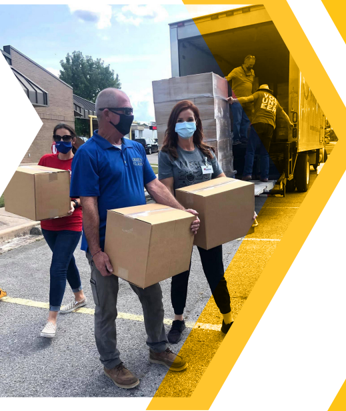

Document ID: 75
Source: AR_2020_WEB2.pdf
Content:
The text in the image is "Midwest Food Bank," which is the name of the organization. It is presented in a serif typeface, which is commonly used for its readability and association with formality and tradition. The text is centered in the image, which gives it a balanced and symmetrical appearance. The color choice for the text is black, which stands out against the white background, ensuring that the text is legible. The text serves as the branding of the organization, indicating its identity and purpose.
Image:


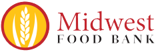

Document ID: 76
Source: AR_2020_WEB2.pdf
Content:
The text in the image, "KEEP MOVING FORWARD," is a motivational phrase that encourages persistence and progress. It is commonly used to inspire and motivate individuals to maintain their efforts and advance in their endeavors, regardless of challenges or setbacks. The message is straightforward and does not contain any complex elements that would require interpretation beyond its literal meaning. It is a simple yet powerful statement that can be applied to various aspects of life, from personal development to professional growth.
Image:


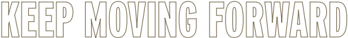

Document ID: 77
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not fully legible due to the resolution and the angle at which the photograph is taken. It appears to be a professional headshot, possibly used for business purposes such as a company website, a professional profile, or a company newsletter. The text, if readable, would likely contain the individual's name, title, and contact information. However, without a clearer image or additional context, it is not possible to provide a detailed transcription of the text.
Image:


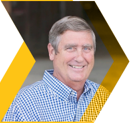

Document ID: 78
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not fully legible due to the overlay and the focus on the subject. However, it appears to be a message or title related to the activity being performed, which is packing or distributing items. The text is in a large, bold font and is placed within a yellow hexagon shape, which is a common design choice for highlighting important information or branding. Without clearer text or additional context, it is not possible to provide a precise interpretation of the text.
Image:


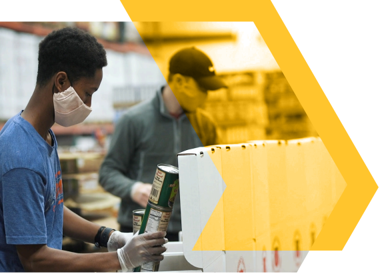

Document ID: 79
Source: AR_2020_WEB2.pdf
Content:
The text in the image is "GROWMARK". It is not a standard English word and does not have a clear meaning without additional context. It could be a brand name, a company, or a specific product. To understand its full context, one would need to search for "GROWMARK" in a search engine or have knowledge of the specific entity it represents. As it stands, it appears to be a text that might be used in a branding or marketing context. If it is a brand, it could be related to agriculture, given the "GROW" part of the text.
Image:


Document ID: 80
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not clearly legible due to the low resolution. However, it appears to be a collection of logos for popular social media platforms, specifically the Facebook, Instagram, and LinkedIn icons. These logos are commonly used in digital media and online content to represent the respective social networking services. The text within these logos is not discernible from the image provided. If the text is intended to be read, it would be found in the respective logos themselves, which are designed to be universally recognizable.
Image:


Document ID: 81
Source: AR_2020_WEB2.pdf
Content:
The text in the image is partially obscured by the yellow background, making it difficult to read completely. However, it appears to be a statement or a slogan associated with the organization mentioned, which is likely involved in food bank services, as indicated by the text "Midwest Food Bank" and the accompanying website "midwestfoodbank.org". The full text cannot be provided due to the image quality and the obscured text. If more information is needed regarding the text, it would be appropriate to search for the organization's official website or contact them directly for accurate and detailed text from their materials.
Image:


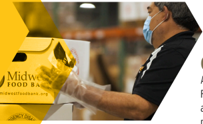

Document ID: 82
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not legible due to the resolution and size of the text. It appears to be a small, white text that could be part of a label, instruction, or branding. Without a clearer image or additional context, it is not possible to accurately describe or interpret the text. If the text is a label or a brand, it might indicate the manufacturer, product line, or a specific feature of the item. However, without more information, any attempt to provide details about the text would be speculative and potentially misleading.
Image:


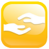

Document ID: 83
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not present; it is a digital icon. Icons like this are typically used to represent a concept or a brand and do not contain text. They are designed to be universally recognizable symbols that can be used in various contexts, from digital applications to branding and marketing materials. The purpose of such icons is to provide a visual cue that can be quickly understood and associated with the concept it represents, without the need for additional text. In this case, the icon is designed to convey a sense of empowerment or success, which is commonly associated with the raised arm gesture.
Image:


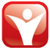

Document ID: 84
Source: AR_2020_WEB2.pdf
Content:
The image contains text, which reads "Green is the new black." This phrase is a play on words, as "green is the new black" is a well-known saying that has been used in various contexts to express that something is now fashionable or in vogue. The text here uses the concept of color to create a pun, linking the literal green color to the figurative meaning of something being "in" or "trendy." It is a visual joke that plays with the viewer's expectations of the text.
Image:


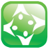

Document ID: 85
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not legible. It appears to be a stylized icon or a logo, potentially for a company or a product, but without clear text, it is not possible to provide an accurate transcription or description of the text. If the text is intended to convey specific information, it would be necessary to have a clearer image or additional context to interpret it correctly. In this case, any attempt to describe the text would be speculative and not based on the available evidence.
Image:


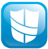

Document ID: 86
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not legible due to its small size and the resolution of the image. Without clearer text, it is not possible to provide an accurate transcription or analysis. If the text is intended to convey a message, it would be necessary to have a higher-resolution image or a clearer text representation to assist with the task. For any text that needs interpretation, it is important to have a clear and legible source to ensure accurate understanding. In this case, providing a transcription or analysis of the text would not be possible.
Image:


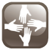

Document ID: 87
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not clearly legible due to the resolution and the angle of the photograph. It appears to be some form of informational text, possibly related to the contents of the boxes or the activities of the individuals. Without a clearer image or additional context, it is not possible to accurately transcribe or interpret the text. If there is a specific message or information you are looking for, it may be necessary to seek a higher resolution image or a clearer source of text.
Image:


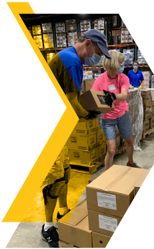

Document ID: 88
Source: AR_2020_WEB2.pdf
Content:
The text in the image is "FOOD INSECURITY". This term refers to a situation where people do not have reliable access to sufficient, safe, and nutritious food. It can be caused by a variety of factors, including poverty, conflict, and environmental degradation. The term is used in the context of discussing the challenges and policies related to ensuring that everyone has adequate access to food. The image does not provide any additional context or information beyond the text itself.
Image:


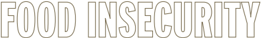

Document ID: 89
Source: AR_2020_WEB2.pdf
Content:
The text in the image is partially obscured and cannot be fully transcribed. However, it appears to be a part of a larger text that is likely intended to convey a message or provide information. Since the text is cut off, it is not possible to determine the exact content or message it is meant to communicate. Without the full text, any attempt to interpret or describe it would be speculative and not based on the visible content of the image. If the text is crucial to understanding the image, it would be recommended to consult the source from which the image was obtained for the complete text.
Image:


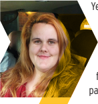

Document ID: 90
Source: AR_2020_WEB2.pdf
Content:
The text in the image is partially obscured and reads "ban pan Hope." It is not fully legible due to the image's resolution and the angle at which the photo is taken. The text appears to be incomplete, with the words "ban" and "pan" being visible, and "Hope" is partially obscured. Without additional context or a clearer image, it is not possible to provide a definitive interpretation of the text. It could be part of a larger message, a brand name, or a slogan. If this text is intended to be read, it might be beneficial to find a higher-resolution image where the text is legible for accurate interpretation.
Image:


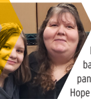

Document ID: 91
Source: AR_2020_WEB2.pdf
Content:
The text present in the image is partially obscured and cannot be read in full. However, from what is visible, it appears to be a mix of a URL or a website address, possibly a social media or news platform, given the common use of such symbols. The text "FB" could stand for Facebook, which is a well-known social networking service. The incomplete text does not provide any additional context or information about the image. Without the full text, it is not possible to provide a detailed analysis of the content or its significance.
Image:


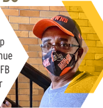

Document ID: 92
Source: AR_2020_WEB2.pdf
Content:
The text in the image, "BERLINDA a bout da," is partially obscured and incomplete. It is not possible to provide a full and accurate transcription of the text as it is not fully visible. The visible portion "BERLINDA" could be a proper noun, possibly a name or a place, and "a bout da" might be a fragment of a phrase or a message. Without additional context or a full view of the text, it is not possible to determine the exact meaning or purpose of the text within the image.
Image:


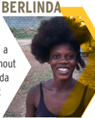

Document ID: 93
Source: AR_2020_WEB2.pdf
Content:
The image contains text that is part of a diagram explaining the flow of donations from "Donations" to "MFB Programs." The text is as follows:

- At the top left, "Donations" is written in a large, bold font.
- In the center, "MFB Programs" is written in a smaller, bold font.
- To the left of "MFB Programs," there are icons representing "Financial," "Food," and "Volunteers."
- To the right of "MFB Programs," there are icons representing "Food Pantrries," "Disaster Relief," "Tender Mercies," and "Hope Packs."

The text serves to categorize and describe the various types of donations and the corresponding programs they support.
Image:


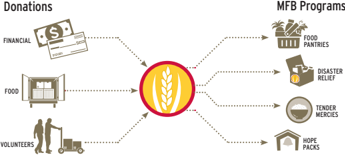

Document ID: 94
Source: AR_2020_WEB2.pdf
Content:
The text in the image is partially obscured, but it appears to be a title or heading for the graph. It mentions "This graph represents sustainable growth in the number of Midwest Food Bank locations and the value of food distributed." The text is too small to read in full, but it suggests that the graph is about the expansion and impact of Midwest Food Bank services. The specific details of the growth and the value of food distributed are not discernible from the image.
Image:


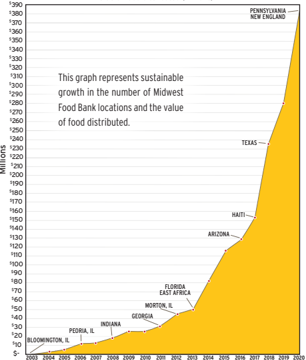

Document ID: 95
Source: AR_2020_WEB2.pdf
Content:
The text in the image reads as follows:
- "13 MILLION SPENT YIELDS $383 MILLION FOOD DISTRIBUTED"
This statement is a play on words, suggesting that a significant amount of money (13 million) spent can yield a substantial outcome (383 million) in the form of food distributed. The image uses visual elements to emphasize the message of efficiency and the impact of investment in food distribution. The use of a shopping basket icon reinforces the theme of food and distribution.
Image:


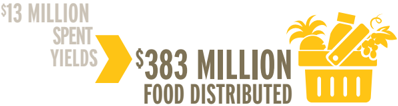

Document ID: 96
Source: AR_2020_WEB2.pdf
Content:
The text in the image is not fully legible due to the resolution and the orientation of the photograph. However, it appears to be a label or a tag on the cardboard boxes, which is common for inventory management in warehouses. This text typically includes details such as the product code, weight, origin, and handling instructions. Since the text is not clear, it is not possible to provide a detailed transcription or interpretation of its content. For accurate text extraction, a clearer image with a better resolution and orientation would be required.
Image:


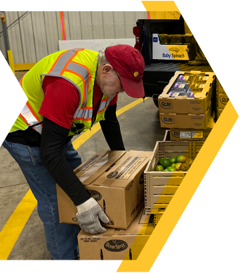

Document ID: 97
Source: AR_2020_WEB2.pdf
Content:
The text in the image is primarily the logo of the Midwest Food Bank, which is an organization that is involved in the distribution of food. The text reads "Midwest Food Bank," with a tagline that includes "Sharing the Blessings," which is a slogan commonly used by food banks to convey their mission of providing assistance to those in need. The tagline "Sharing the Blessings" suggests a philosophy of charity and community support. The text is clear and legible, with a large, bold font used for the main text and a smaller font for the tagline, which helps to emphasize the organization's name while also giving credit to the cause. The text is integral to the image as it identifies the organization and the purpose of the scene, which is to give food to those who are hungry.
Image:


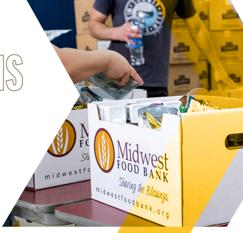

In [12]:
import itertools
from docling_core.types.doc.document import RefItem
from IPython.display import display

# Print all created documents
for document in itertools.chain(texts, tables):
    print(f"Document ID: {document.metadata['doc_id']}")
    print(f"Source: {document.metadata['source']}")
    print(f"Content:\n{document.page_content}")
    print("=" * 80)  # Separator for clarity

for document in pictures:
    print(f"Document ID: {document.metadata['doc_id']}")
    source = document.metadata['source']
    print(f"Source: {source}")
    print(f"Content:\n{document.page_content}")
    docling_document = conversions[source]
    ref = document.metadata['ref']
    picture = RefItem(cref=ref).resolve(docling_document)
    image = picture.get_image(docling_document)
    print("Image:")
    if image:
        display(image)
    else:
        print(f"  [Image for {ref} not available or could not be retrieved]")
    print("=" * 80)  # Separator for clarity

## Populate the vector database

Using the embedding model, we load the documents from the text chunks and generated image captioning into a vector database. Creating this vector database allows us to easily conduct a semantic similarity search across our documents.

NOTE: Population of the vector database can take some time depending on your embedding model and service.

### Choose your vector database

Specify the database to use for storing and retrieving embedding vectors.

To connect to a vector database other than ChromaDB, replace this code cell with one from [this Vector Store recipe](https://github.com/ibm-granite-community/granite-kitchen/blob/main/recipes/Components/Langchain_Vector_Stores.ipynb).

In [13]:
from langchain_core.vectorstores import VectorStore
from langchain_chroma import Chroma

vector_db: VectorStore = Chroma(embedding_function=embeddings_model)

We now add all the LangChain documents for the text, tables and image descriptions to the vector database.

In [14]:
import itertools

documents = list(itertools.chain(texts, tables, pictures))
ids = vector_db.add_documents(documents)

# Get the total expected number of pictures from the original documents
expected_pictures_count = 0
for docling_document in conversions.values():
    expected_pictures_count += len(docling_document.pictures)

print(f"{len(ids)} documents added to the vector database.")
if len(pictures) < expected_pictures_count:
    print(f"Warning: Only {len(pictures)} out of an expected {expected_pictures_count} image descriptions were processed and added to the vector database due to an interrupted execution in a previous step. Please ensure cell 'M7h-PLloG-2r' runs to completion to include all image descriptions.")

97 documents added to the vector database.


## Step 4: RAG with Granite

Now that we have successfully converted our documents and vectorized them, we can set up out RAG pipeline.

### Retrieve relevant chunks



Here we test the vector database by searching for chunks with relevant information to our query in the vector space. We display the documents associated with the retrieved image description.

Feel free to try different queries.

In [15]:
query = "How much was spent on food distribution relative to the amount of food distributed?"
retrieved_docs = vector_db.as_retriever().invoke(query)

if not retrieved_docs:
    print("No relevant documents found for the query in the vector database.")
    print("This might be due to the incompleteness of the vector database from a previous interrupted execution.")
    print("Consider re-running cell 'M7h-PLloG-2r' to ensure all image descriptions are processed and then re-run this cell.")
else:
    for i, doc in enumerate(retrieved_docs):
        print(f"--- Retrieved Document {i+1} ---")
        print(doc)
        print("=" * 80)  # Separator for clarity

--- Retrieved Document 1 ---
page_content='Midwest Food Bank Growth Value of food distributed (millions) Value of food distributed (millions)' metadata={'ref': '#/texts/141', 'source': 'AR_2020_WEB2.pdf', 'doc_id': 15}
--- Retrieved Document 2 ---
page_content='The text in the image reads as follows:
- "13 MILLION SPENT YIELDS $383 MILLION FOOD DISTRIBUTED"
This statement is a play on words, suggesting that a significant amount of money (13 million) spent can yield a substantial outcome (383 million) in the form of food distributed. The image uses visual elements to emphasize the message of efficiency and the impact of investment in food distribution. The use of a shopping basket icon reinforces the theme of food and distribution.' metadata={'source': 'AR_2020_WEB2.pdf', 'doc_id': 95, 'ref': '#/pictures/21'}
--- Retrieved Document 3 ---
page_content='The text in the image is partially obscured, but it appears to be a title or heading for the graph. It mentions "This graph represents su

The returned document should be responsive to the query. Let's go ahead and construct our RAG pipeline.

### Create the RAG pipeline for Granite

First we create the prompts for Granite to perform the RAG query. We use the Granite chat template and supply the placeholder values that the LangChain RAG pipeline will replace.

Next, we construct the RAG pipeline by using the Granite prompt templates previously created.


In [19]:
from ibm_granite_community.langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_core.prompts import ChatPromptTemplate

# Create a Granite prompt for question-answering with the retrieved context
prompt_template = ChatPromptTemplate.from_template(
    """You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Your answer should be three sentences maximum and concise. Do not include any additional notes or meta-commentary about the answer, such as comments about its conciseness or reference to the context.

Question: {input}
Context: {context}
Answer:"""
)

# Assemble the retrieval-augmented generation chain
combine_docs_chain = create_stuff_documents_chain(
    llm=model,
    prompt=prompt_template,
)
rag_chain = create_retrieval_chain(
    retriever=vector_db.as_retriever(),
    combine_docs_chain=combine_docs_chain,
)

### Generate a retrieval-augmented response to a question

The pipeline uses the query to locate documents from the vector database and use them as context for the query.

In [18]:
from ibm_granite_community.notebook_utils import wrap_text

output = rag_chain.invoke({"input": query})

print("Raw RAG chain output:")
print(output)
print("\n" + "=" * 80 + "\n")

if output and 'answer' in output and output['answer'].strip():
    print("Generated Answer:")
    print(wrap_text(output['answer']))
else:
    print("The RAG chain returned an empty or no answer.")
    print("This might be due to the LLM's configuration (e.g., 'min_tokens' being too high for a concise answer) or the prompt not eliciting a response.")
    print("Consider reviewing the 'model_kwargs' in cell 'Ckyj7Zrh_JRK' and the prompt template in 'PB-CPPTo_JRL'.")

Raw RAG chain output:
{'input': 'How much was spent on food distribution relative to the amount of food distributed?', 'context': [Document(id='e8e25e6f-60c3-4646-b9e1-c452a709bf0b', metadata={'ref': '#/texts/141', 'source': 'AR_2020_WEB2.pdf', 'doc_id': 15}, page_content='Midwest Food Bank Growth Value of food distributed (millions) Value of food distributed (millions)'), Document(id='a1e86872-1434-42be-a498-4cbdd62de706', metadata={'doc_id': 95, 'ref': '#/pictures/21', 'source': 'AR_2020_WEB2.pdf'}, page_content='The text in the image reads as follows:\n- "13 MILLION SPENT YIELDS $383 MILLION FOOD DISTRIBUTED"\nThis statement is a play on words, suggesting that a significant amount of money (13 million) spent can yield a substantial outcome (383 million) in the form of food distributed. The image uses visual elements to emphasize the message of efficiency and the impact of investment in food distribution. The use of a shopping basket icon reinforces the theme of food and distribution

Awesome! We have created an AI application that can successfully leverage knowledge from the source documents' text and images.

## Next Steps

- Explore advanced RAG workflows for other industries.
- Experiment with other document types and larger datasets.
- Optimize prompt engineering for better Granite responses.

Thank you for using this recipe!